## Load the Processed Dataset

### Why
The feature-engineered dataset created in Group 1 is loaded for predictive modeling.  
This dataset already contains cleaned data and engineered features, making it suitable for training machine learning models.

### What we expect
After loading the dataset, we verify that all features required for price prediction are available.

In [3]:
import pandas as pd

df = pd.read_csv("feature_engineered_dataset_v4.csv")

df.head()

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,STAFFORD ST,2,6000.0,1092.0,1.0,WRIGHT,2024-07-01 00:00:00+00:00,...,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,STAFFORD ST,2,6000.0,936.0,1.0,SANTANA,2022-04-26 00:00:00+00:00,...,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,STAFFORD ST,2,6000.0,1111.0,1.0,MARTINEZ,2023-12-22 00:00:00+00:00,...,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,NEWINGTON AVE,2,5040.0,1684.0,1.0,CAHUANA FLORES,2021-01-11 00:00:00+00:00,...,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,BRISTOL ST,2,6000.0,900.0,1.0,NEGRON,2021-09-21 00:00:00+00:00,...,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


## Define Features and Target Variable

### Why
To build a predictive model, we separate the dataset into:
- **Features (X)** → variables used to predict price  
- **Target (y)** → the value we want to predict

Here, the target variable is **LogSalePrice**, which represents the logarithm of the property sale price.

### What we expect
After this step, the dataset will be separated into:
- input variables used by the model
- the output variable representing property price

In [7]:
X = df[["PricePerSqft", "AppraisalRatio"]]
y = df["LogSalePrice"]

print(X.head())
print("\nTarget variable:", y.name)

   PricePerSqft  AppraisalRatio
0    237.179487        1.383547
1    222.222222        1.081643
2    112.511251        0.842318
3    105.106888        0.894391
4    208.888889        1.101347

Target variable: LogSalePrice


## Train-Test Split

### Why
To evaluate the predictive model properly, the dataset is divided into two parts:

- **Training data** – used to train the model and learn patterns
- **Testing data** – used to evaluate how well the model performs on unseen data

This helps ensure that the model generalizes well instead of simply memorizing the training data.

### What we expect
80% of the data will be used for training and 20% for testing.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3652
Testing samples: 914


## Linear Regression Model

Train a linear regression model to predict LogSalePrice using PricePerSqft and AppraisalRatio.

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

ValueError: Input X contains infinity or a value too large for dtype('float64').

Error is happening because PricePerSqft or AppraisalRatio contains inf values.

## Handle Infinite Values

Replace infinite values created during feature engineering with NaN and remove them so the model can train properly.

In [17]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)

# remove rows with NaN
X = X.dropna()
y = y.loc[X.index]

print("Cleaned dataset size:", X.shape)

Cleaned dataset size: (4564, 2)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

###########
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Training samples: 3651
Testing samples: 913
Model trained successfully


## Model Prediction

Use the trained Linear Regression model to predict LogSalePrice on the testing dataset.

In [26]:
y_pred = model.predict(X_test)

print("First 5 predictions:")
print(y_pred[:5])

First 5 predictions:
[11.95430929 11.94485144 11.93702853 11.9524163  11.95981521]


## Model Evaluation

Evaluate the prediction performance using common regression metrics such as R² score and Mean Absolute Error (MAE).

In [29]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("Mean Absolute Error:", mae)

R² Score: 0.3212296235163452
Mean Absolute Error: 0.7631412297663992


## Insights from Model Evaluation

The Linear Regression model achieved an **R² score of 0.32**, meaning the model explains about **32% of the variation in property sale prices** using the selected features.

The **Mean Absolute Error (MAE) of 0.76** indicates the average difference between the predicted and actual LogSalePrice values.

This suggests that while **PricePerSqft and AppraisalRatio capture some relationship with property prices**, additional features such as location, property size, and neighborhood characteristics may be needed to improve prediction accuracy.

## Actual vs Predicted Price Comparison

Visualize how close the predicted LogSalePrice values are to the actual values.  
If the model performs well, the points should lie close to the diagonal line.

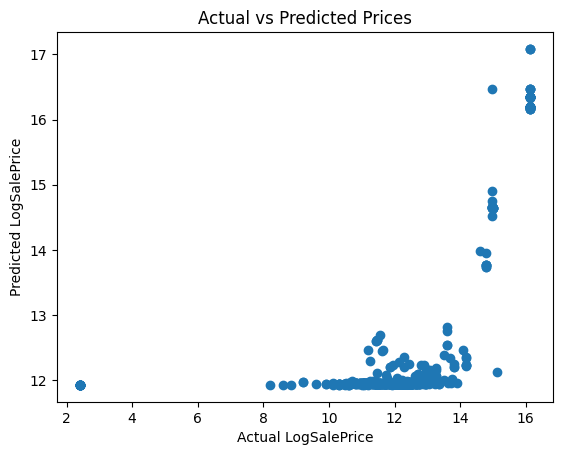

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual LogSalePrice")
plt.ylabel("Predicted LogSalePrice")
plt.title("Actual vs Predicted Prices")

plt.show()

## Insights from Actual vs Predicted Plot

The scatter plot compares the **actual LogSalePrice values with the predicted values** from the Linear Regression model.

Many points are **spread away from the ideal diagonal trend**, indicating that the model predictions are not very close to the actual values for several properties.

This suggests that while **PricePerSqft and AppraisalRatio contribute to price prediction**, they alone are not sufficient to fully explain variations in property prices. Other factors such as **location, neighborhood, land size, and property characteristics** likely influence the sale price and could improve model performance if included.

### Insights from Random Forest Model

The Random Forest model further improves prediction performance by combining multiple decision trees.

Compared to individual models, Random Forest typically reduces overfitting and provides more stable predictions.  
If the R² score increases and MAE decreases, it indicates that ensemble learning improves the model’s ability to predict property prices.

This suggests that combining multiple decision trees helps capture complex pricing patterns more effectively.

## Decision Tree Regression

Train a Decision Tree model to capture non-linear relationships between the features and property prices.

In [37]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree trained")

Decision Tree trained


### Decision Tree Evaluation

Evaluate the performance of the Decision Tree model using R² and MAE.

In [44]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

dt_r2 = r2_score(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

print("Decision Tree R²:", dt_r2)
print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)

Decision Tree R²: 0.8750932618572683
Decision Tree MAE: 0.42824116371409715
Decision Tree RMSE: 0.6663961928329408


### Insights from Decision Tree Model

The Decision Tree model achieved an **R² score of 0.875**, meaning it explains about **87.5% of the variation in property prices**. This indicates that the model captures the relationship between the features and the target variable very well.

The **Mean Absolute Error (MAE) of 0.428** shows that the average difference between predicted and actual LogSalePrice values is relatively small, indicating strong prediction accuracy.

The **Root Mean Squared Error (RMSE) of 0.666** suggests that most prediction errors are moderate, though some larger deviations still exist.

Compared to Linear Regression, the Decision Tree model performs significantly better, indicating that **property price patterns are likely non-linear** and better captured by tree-based models.

Overall, the Decision Tree model provides a **much stronger predictive performance for estimating property prices** using the selected features.

## Random Forest Model

### Why

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions.  
This helps improve prediction accuracy and reduces overfitting compared to a single Decision Tree.

### What we expect

The model should capture more complex patterns in property pricing and potentially improve prediction accuracy.

In [48]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [50]:
rf_pred = rf_model.predict(X_test)

print("First 5 Random Forest predictions:")
print(rf_pred[:5])

First 5 Random Forest predictions:
[12.64394606 12.20055312  9.1666266  12.35427877 12.48051412]


In [52]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest R²:", rf_r2)
print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest R²: 0.9287560993521942
Random Forest MAE: 0.3416277410938729
Random Forest RMSE: 0.50328434122191


### Insights from Random Forest Model

The Random Forest model achieved an **R² score of 0.929**, meaning it explains about **92.9% of the variation in property prices**. This is the highest performance among the models tested.

The **MAE of 0.342** indicates that the average difference between predicted and actual LogSalePrice values is relatively small, showing strong prediction accuracy.

The **RMSE of 0.503** suggests that most prediction errors are moderate and significantly lower compared to the previous models.

Compared to Linear Regression and Decision Tree models, Random Forest provides the **best predictive performance**, indicating that combining multiple decision trees helps capture complex relationships in property pricing.

Overall, Random Forest is the **most reliable model for predicting property prices in this dataset**.

## Gradient Boosting Model

### Why

Gradient Boosting is an ensemble learning method that builds multiple decision trees sequentially.  
Each new tree learns from the errors of the previous trees, helping improve prediction accuracy.

### What we expect

Because Gradient Boosting corrects previous mistakes during training, it may capture complex patterns in property pricing and potentially outperform earlier models.

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully")

Gradient Boosting model trained successfully


In [58]:
gb_pred = gb_model.predict(X_test)

print("First 5 Gradient Boosting predictions:")
print(gb_pred[:5])

First 5 Gradient Boosting predictions:
[12.47211552 12.33913311  9.39941359 12.17052287 12.40176744]


In [60]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

gb_r2 = r2_score(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("Gradient Boosting R²:", gb_r2)
print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting R²: 0.933930087243336
Gradient Boosting MAE: 0.34302354579630134
Gradient Boosting RMSE: 0.48466475668297626


### Insights from Gradient Boosting Model

The Gradient Boosting model achieved an **R² score of 0.934**, meaning it explains about **93.4% of the variation in property prices**. This is slightly better than the Random Forest model and significantly better than Linear Regression.

The **MAE of 0.343** indicates that the average prediction error between predicted and actual LogSalePrice values is relatively small.

The **RMSE of 0.485** suggests that overall prediction errors are low and the model handles larger deviations better than previous models.

Because Gradient Boosting learns sequentially and corrects the mistakes of previous trees, it is able to capture **complex non-linear relationships in property pricing**.

Overall, Gradient Boosting currently provides the **best predictive performance among the tested models**.

In [65]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "R2 Score": [r2, dt_r2, rf_r2, gb_r2],
    "MAE": [mae, dt_mae, rf_mae, gb_mae],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        dt_rmse,
        rf_rmse,
        gb_rmse
    ]
})

comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.321230,0.763141,1.553463
1,Decision Tree,0.875093,0.428241,0.666396
2,Random Forest,0.928756,0.341628,0.503284
3,Gradient Boosting,0.933930,0.343024,0.484665


### Model Comparison Insights

The model comparison shows clear differences in prediction performance.

Linear Regression performed the worst with an R² score of **0.32**, meaning it explains only about **32% of the variation in property prices**. This indicates that property pricing relationships are not purely linear.

The Decision Tree model significantly improved performance with an **R² of 0.875**, showing that non-linear models better capture property pricing patterns.

Random Forest further improved performance with an **R² of 0.929** and lower error values, demonstrating the advantage of ensemble learning.

Gradient Boosting achieved the **best overall performance** with the **highest R² (0.934)** and the **lowest RMSE (0.485)**. This indicates that it provides the most accurate predictions among the tested models.

Overall, the results suggest that **ensemble tree-based models are most effective for predicting property prices**, as they can capture complex relationships between pricing factors.